---
<b>CPVAE "Conditional Prior VAE" with deep conditional inputs</b>

---
<ul><li>Dataset: synthetic sequential data, spatial coordinates of nodes converted to relative distances and radians for training (invariance)
</li>
<li>Encoder and decoder are trained using a mixture of X values (coordinates) and y values (categories)</li>
<li>Goal is to force the latent space to organize according to y</li>
<li>Result shows the latent space organize according both to X data (sizes, global transformations), and to y data (categories)</li></ul>


In [ ]:
import importlib, sys

import numpy as np
import random
random.seed(42)

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', edgecolor='#999999',linewidth=0.4, labelsize=8, titlesize=10)
mpl.rc('xtick', labelsize=8, color='#666666')
mpl.rc('ytick', labelsize=8, color='#666666')
mpl.rc('grid', color='#999999',linewidth=0.2)
mpl.rc('text', color='#666666')
mpl.rc('legend', fontsize=8)
mpl.rc('font', family='Menlo')

from sklearn.manifold import TSNE

Next cell defines rules for creating sequences of pseudo-AA (router dict), with limited options

Then most popular subsequences are identified

These popular subsequences (chunks) will qualify later the coordinates (2D) of the pseudo-proteins

In [2]:
from collections import Counter

router = {
    'a': ['c','d'],
    'b': ['a','e'],
    'c': ['c','d','h'],
    'd': ['i','g'],
    'e': ['a','j'],
    'f': ['f','h','i'],
    'g': ['a','h'],
    'h': ['g','i'],
    'i': ['e','a'],
    'j': ['a','b','f','h']
}

aa = list(router.keys())

def getSequence(length = 5):
    sequence = random.choice(aa)
    for _ in range(length-1):
        sequence += random.choice(router[sequence[-1]])
    return sequence

random_chunks = [getSequence() for _ in range(20000)]

most_popular_sequences = Counter(random_chunks).most_common(10)
print (most_popular_sequences)

most_popular_sequences = [item[0] for item in most_popular_sequences]
print (most_popular_sequences)

sequences = [getSequence(30) for _ in range(20)]

matches = [1 if any(sub in SEQ for sub in most_popular_sequences) else 0 for SEQ in sequences]

print (f"Matches {sum(matches)}")

[('adgad', 145), ('ghiea', 144), ('ghgac', 144), ('hieac', 139), ('adghi', 139), ('beadi', 139), ('ghiej', 139), ('badie', 138), ('eadia', 138), ('badia', 137)]
['adgad', 'ghiea', 'ghgac', 'hieac', 'adghi', 'beadi', 'ghiej', 'badie', 'eadia', 'badia']
Matches 17


<b>Next cell defines functions to generate 2D coords from protein sequence and its invariant corrolar (distance + angle)

<b>And the reverse function, that will translate the model ouput from [distance, coordinate] to (x,y) coordinates.

<b>"special_paths" are applied accordingly to most popular subsequences, ensuring that most of the pseudo-proteins show similar spatial subsequences

In [ ]:
special_paths = [
    [[2., np.pi], [5., np.pi * 0.75], [5., np.pi], [5., np.pi * -0.75], [2., np.pi]], # Zig-zag
    [[4., np.pi], [5., np.pi * 0.5], [5., np.pi], [5., np.pi * 0.5], [4., np.pi]], # U-Turn
    [[3., np.pi], [5., np.pi * -0.5], [5., np.pi], [5., np.pi * -0.5], [3., np.pi]], # U-Turn
    [[4., np.pi], [5., np.pi * 1.125], [5., np.pi * 1.125], [5., np.pi * 1.125], [4., np.pi * 1.125]], # 90 degrees
    [[6., np.pi], [4., np.pi * 0.875], [4., np.pi * 0.875], [4., np.pi * 0.875], [6., np.pi * 0.875]] # -90 degrees
]

def get_dist_angle_from_sequence(sequence):
    inva = [[3.,np.pi],[3.,np.pi],[3.,np.pi],[3.,np.pi],[3.,np.pi]]
    for i in range(5, len(sequence)):
        chunk = sequence[i-5:i]
        if chunk in most_popular_sequences:
            idx = most_popular_sequences.index(chunk) % 5
            inva[i-4:] = special_paths[idx]
        else:
            inva.append([3.,np.pi])
    return inva

def move_point(point, distance, angle_rad):
    x, y = point
    dx = distance * np.cos(angle_rad)
    dy = distance * np.sin(angle_rad)
    return np.array([x + dx, y + dy])

def reconstruct_from_invariant(inva, start_point=(0.0, 0.0), start_angle=0.0):
    coords = [np.array(start_point)]

    # First segment
    first_dist = inva[0, 0]
    current_angle = start_angle
    p1 = move_point(coords[0], first_dist, current_angle)
    coords.append(p1)

    for i in range(1, len(inva)):
        d_next = inva[i, 0]
        internal_angle = inva[i, 1]

        # Calculate exterior turning angle (how direction changes)
        turning_angle = np.pi - internal_angle
        current_angle -= turning_angle

        next_point = move_point(coords[-1], d_next, current_angle)
        coords.append(next_point)

    return np.array(coords)

sample = sequences[0]
print (sample)
inva = get_dist_angle_from_sequence(sample)
print (len(sample), len(inva))

<b>Please install this useful library, outputs SVG embedded drawings, very clean in notebooks</b>

In [ ]:
!pip install svgwrite

In [4]:
import svgwrite
from IPython.display import display, SVG

def draw(input_data, labels=[], title='default.svg', size=400, show=True):

    interspace = 40
    margin = 20
    radius = 4
        
    size_x, size_y = (len(input_data) * size) + (len(input_data) * interspace), size
    dwg = svgwrite.Drawing('_svg/'+title, size=(size_x, size_y))
    
    for i in range(len(input_data)):

        coords = input_data[i].copy()
        coords -= coords.min()
        coords /= coords.max()
        
        coords *= (size - margin - 100)
        
        coords[:,0] += margin + i * (size + interspace)
        coords[:,1] += 100

        dwg.add(dwg.polyline(points=coords, stroke="black", fill="none", stroke_width=1.))

        for coord in coords:
            node = dwg.circle(center=(coord[0],coord[1]), r=radius).fill('white').stroke(color="black", width=2.)
            dwg.add(node)

        if i<len(labels):
            dwg.add(dwg.text(labels[i], insert=(margin - radius + i * (size+interspace), size - margin + 15), 
                             fill="black", font_size="12px", font_family="Menlo"))
            
    if show: display(SVG(dwg.tostring()))
    return dwg

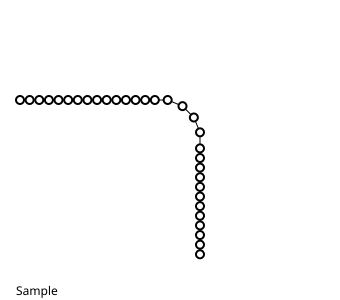

In [128]:
sample = sequences[0]
inva = reconstruct_from_invariant(np.array(get_dist_angle_from_sequence(sample)))
_ = draw([inva],['Sample'], size=300)

<b>Pseudo-protein and Dataset class definition</b>

Sequence :        iachieaccccdgac
Sequence length : 15
Special chunks :  [0. 0. 0. 1. 0.]
Transformation :  -1
Data :            (15, 2)



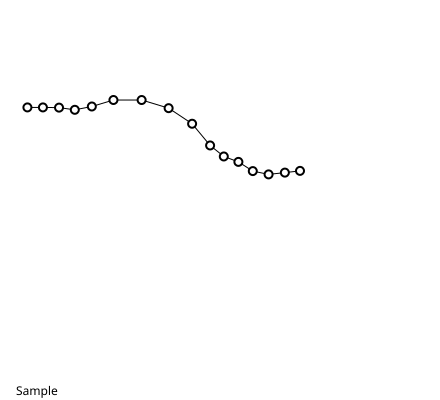

In [6]:
def one_hot(labels, num_classes):
    return np.eye(num_classes)[labels]
    
class Protein:
    def __init__(self, length=10, sequence=False, transformation=0.):
        self.len = length
        self.sequence = sequence
        self.special_chunks = []
        self.global_trans = transformation

        if sequence == False:
            self._setSequence()

        self._get_dist_angle_from_sequence()
        
        if transformation != 0:
            self.global_transformation()

    def _setSequence(self):
        sequence = random.choice(aa)
        for _ in range(self.len-1):
            sequence += random.choice(router[sequence[-1]])
        self.sequence = sequence

    def _get_dist_angle_from_sequence(self, variance=0.1):
        inva = [[(1 + np.random.uniform(-variance, variance)) * 3., (1 + np.random.uniform(-variance, variance)) * np.pi] for _ in range(5)]
        for i in range(5, len(self.sequence)):
            chunk = self.sequence[i-5:i]
            if chunk in most_popular_sequences:
                idx = most_popular_sequences.index(chunk) % 5
                self.special_chunks.append(idx)
                inva[i-4:] = special_paths[idx]
            else:
                inva.append([(1 + np.random.uniform(-variance, variance)) * 3., (1 + np.random.uniform(-variance, variance)) * np.pi])
        self.invariant = np.array(inva)
        self.coords = reconstruct_from_invariant(self.invariant)
        mask = np.array(list(set(self.special_chunks)))
        self.special_chunks = np.zeros((5))
        if mask.sum() > 0: self.special_chunks[mask] = 1.

    def global_transformation(self, transformation=False):
        if transformation is not False:
            self.global_trans = transformation
        self.invariant[:,1] += self.global_trans * 0.1
        self.coords = reconstruct_from_invariant(self.invariant)
        
    def draw(self, size=200):
        _ = draw([self.coords], ['Sample'], size=size)
        
    def __repr__(self):
        s =  f'Sequence :        {self.sequence}\n'
        s += f'Sequence length : {self.len}\n'
        s += f'Special chunks :  {self.special_chunks}\n'
        s += f'Transformation :  {self.global_trans}\n'
        s += f'Data :            {self.invariant.shape}\n'
        return s
        
P = Protein(15, transformation=-1)
print (P)
P.draw(size=400)

Dataset with 6600 samples

Sequence :        ghiejhgadghghie
Sequence length : 15
Special chunks :  [0. 1. 0. 0. 0.]
Transformation :  -3
Data :            (15, 2)



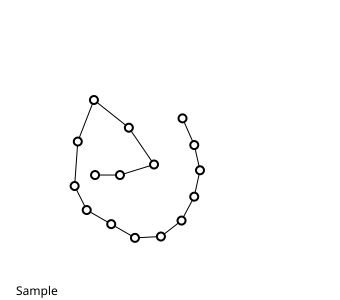

In [110]:
class Dataset:
    def __init__(self):
        self.proteins = []

    def generate(self, min_len, max_len, samples, transformations=range(0, 1)):
        objects = []
        for _ in range(samples):
            for num_nodes in range(min_len, max_len+1):
                for transformation in transformations:
                    P = Protein(num_nodes, transformation=transformation)
                    self.proteins.append(P)
    
    @property
    def len(self):
        return len(self.proteins)

    def __getitem__(self, idx):
        return self.proteins[idx]

    @property
    def max_nodes(self):
        return max([p.len for p in self.proteins])

DS = Dataset()
DS.generate(15, 25, samples=100, transformations=range(-3, 3))

print (f'Dataset with {DS.len} samples')
print ('')
print (DS[0])
DS[0].draw(size=300)

<b>Functions to "standardize" data, in and out, so model outputs will need to be reversed transformed before display</b>

In [111]:
stat_data = np.zeros((0, 2))

for protein in DS:
    item = np.zeros((1, 2))
    stat_data = np.vstack([protein.invariant, item])
    
print (stat_data.shape)

MIN, MAX = stat_data.min(axis=0), stat_data.max(axis=0)
print ('MIN', MIN)
print ('MAX', MAX)

def transform_in(data, MIN, MAX):
    transformed = (data - MIN) / ((MAX - MIN) + 1e-6)
    return transformed

def transform_out(data, MIN, MAX):
    transformed = (data * ((MAX - MIN) + 1e-6)) + MIN
    return transformed

(26, 2)
MIN [0. 0.]
MAX [3.29520078 3.65205841]


# Data preparation

In [112]:
train_data = np.zeros((0, DS.max_nodes, 2))
label_data = np.zeros((0, len(DS[0].special_chunks)))

for protein in DS:
    item = np.zeros((1, DS.max_nodes, 2))
    data = transform_in(protein.invariant, MIN, MAX)
    item[:,:data.shape[0],:data.shape[1]] = data
    train_data = np.vstack([train_data, item])
    label_data = np.vstack([label_data, protein.special_chunks])
    
print (train_data.shape)
print (label_data.shape)
train_data[0]

(6600, 25, 2)
(6600, 5)


array([[0.84821142, 0.8101149 ],
       [1.21388621, 0.77807953],
       [1.51735776, 0.34796705],
       [1.51735776, 0.77807953],
       [1.51735776, 0.34796705],
       [1.51735776, 0.77807953],
       [0.91494847, 0.71322587],
       [0.96275691, 0.70069543],
       [0.93373728, 0.86082798],
       [0.88431737, 0.70245563],
       [0.88698668, 0.69415003],
       [0.92127938, 0.74414958],
       [0.91973585, 0.78530746],
       [0.88049055, 0.74022658],
       [0.9926667 , 0.80799253],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ],
       [0.        , 0.        ]])

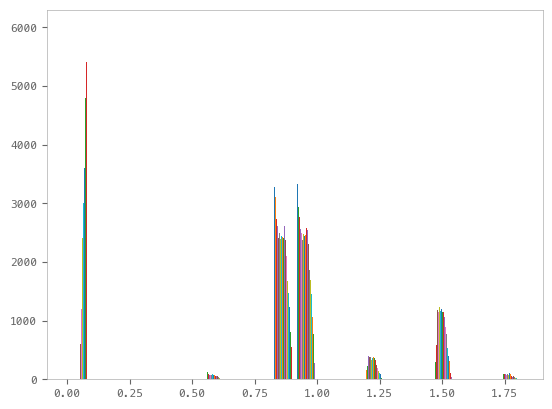

In [113]:
# what's in there?

_ = plt.hist(train_data[:,:,0], bins=20)
plt.show()

In [114]:
#importlib.reload(sys.modules['classes.VAE'])
#importlib.reload(sys.modules['functions.training'])

import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as DL
from torch.utils.data import Dataset, TensorDataset

class CustomDataset(TensorDataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.labels[idx]
        return x, y

train_data = torch.tensor(train_data, dtype=torch.float32)
label_data = torch.tensor(label_data, dtype=torch.float32)

TRAIN_x =  train_data[:int(DS.len*0.9)]
TRAIN_x =  TRAIN_x.view(TRAIN_x.size(0),-1)
TEST_x =   train_data[int(DS.len*0.9):]
TEST_x =   TEST_x.view(TEST_x.size(0),-1)
TRAIN_y =  label_data[:int(DS.len*0.9)]
TEST_y =   label_data[int(DS.len*0.9):]

print ('Train x shape', TRAIN_x.shape, 'Test x shape', TEST_x.shape)
print ('Train y shape', TRAIN_y.shape, 'Test y shape', TEST_y.shape)

batch_size =          32
Train_dataset =       CustomDataset(TRAIN_x, TRAIN_y)
Train_dataloader =    DL(Train_dataset, batch_size=batch_size, shuffle=False)
Test_dataset =        CustomDataset(TEST_x, TEST_y)
Test_dataloader =     DL(Test_dataset, batch_size=batch_size, shuffle=False)

Train x shape torch.Size([5940, 50]) Test x shape torch.Size([660, 50])
Train y shape torch.Size([5940, 5]) Test y shape torch.Size([660, 5])


# Model training

<b>External .py files loaded, CPVAE and training</b>

<b>Training process embedded in "Training" object, see file for construction</b>

<b>Check special kl-loss function in there, X (mu, logvar) according to conditional y (mu, logvar): <b>

<code>
    @staticmethod
    def conditional_kl(mu_q, logvar_q, mu_p, logvar_p):
        return 0.5 * torch.sum(
            logvar_p - logvar_q +
            (torch.exp(logvar_q) + (mu_q - mu_p).pow(2)) / torch.exp(logvar_p) - 1
        )
</code>

In [115]:
importlib.reload(sys.modules['classes.CPVAE'])
importlib.reload(sys.modules['functions.training'])

from classes.CPVAE import *
from functions.training import *

code_size =           32
input_size =          TRAIN_x.shape[-1]
label_size =          len(DS[0].special_chunks)
label_hidden_size =   32
hidden_size =         64
epochs =              100
lr =                  1e-5
kl_sigma =            1e-5

model = CPVAE(input_size=input_size, label_size=label_size, label_hidden_size=label_hidden_size, hidden_size=hidden_size, code_size=code_size)
optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.99, momentum=0.9)
model.apply(model.weights_init)

Trainer = Training(name='CPVAE', model=model, optimizer=optimizer, model_class='CPVAE', with_kl=True)
Trainer.train(Train_dataloader, Test_dataloader, kl_sig=kl_sigma, loss_type='MSE', epochs=epochs, prints=20, verbose=False, loss_enlarge=10000)

5940 training samples, 660 test samples
Loss per item multiplied 10000 times.

Epoch [     1/100] Train KL-L:    177477.10 | Train RECON-L:    370573.65 | Test KL-L:    176517.39 | Test RECON-L:    362620.15
Epoch [     6/100] Train KL-L:    178051.27 | Train RECON-L:    351044.19 | Test KL-L:    177000.77 | Test RECON-L:    341947.27
Epoch [    11/100] Train KL-L:    180134.23 | Train RECON-L:    323905.86 | Test KL-L:    178770.32 | Test RECON-L:    316502.63
Epoch [    16/100] Train KL-L:    184186.32 | Train RECON-L:    295585.75 | Test KL-L:    182382.22 | Test RECON-L:    290084.72
Epoch [    21/100] Train KL-L:    191319.27 | Train RECON-L:    266500.53 | Test KL-L:    188873.33 | Test RECON-L:    262754.59
Epoch [    26/100] Train KL-L:    203416.04 | Train RECON-L:    238262.52 | Test KL-L:    199803.46 | Test RECON-L:    236276.66
Epoch [    31/100] Train KL-L:    221207.31 | Train RECON-L:    214475.51 | Test KL-L:    214991.97 | Test RECON-L:    213770.66
Epoch [    36/100]

In [117]:
Trainer.train(Train_dataloader, Test_dataloader, kl_sig=kl_sigma, loss_type='MSE', epochs=10000, prints=50, verbose=False, loss_enlarge=10000)

5940 training samples, 660 test samples
Loss per item multiplied 10000 times.

Epoch [     1/10000] Train KL-L:    262714.59 | Train RECON-L:     64749.05 | Test KL-L:    251756.78 | Test RECON-L:     64436.51
Epoch [   201/10000] Train KL-L:    320440.76 | Train RECON-L:     47044.51 | Test KL-L:    308448.45 | Test RECON-L:     46426.98
Epoch [   401/10000] Train KL-L:    544727.59 | Train RECON-L:     40888.03 | Test KL-L:    513151.40 | Test RECON-L:     40753.20
Epoch [   601/10000] Train KL-L:    983179.29 | Train RECON-L:     34306.63 | Test KL-L:    927038.53 | Test RECON-L:     34354.82
Epoch [   801/10000] Train KL-L:   1679032.62 | Train RECON-L:     23122.20 | Test KL-L:   1598010.18 | Test RECON-L:     23244.55
Epoch [  1001/10000] Train KL-L:   2198105.43 | Train RECON-L:     20105.18 | Test KL-L:   2112180.63 | Test RECON-L:     20389.44
Epoch [  1201/10000] Train KL-L:   2619347.85 | Train RECON-L:     18076.45 | Test KL-L:   2534339.49 | Test RECON-L:     18561.14
Epoc

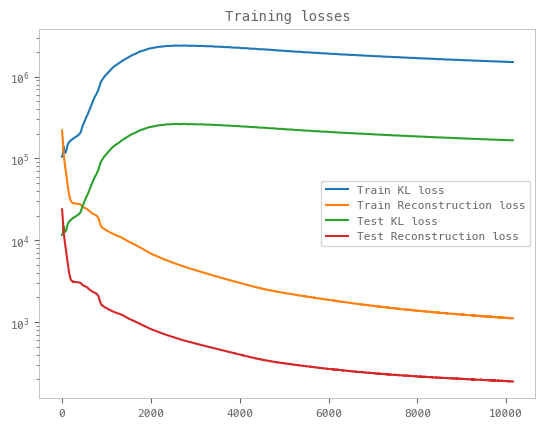

In [118]:
hist = Trainer.history

plt.plot(hist['train_kl_losses'], label='Train KL loss')
plt.plot(hist['train_recon_losses'], label='Train Reconstruction loss')
plt.plot(hist['test_kl_losses'], label='Test KL loss')
plt.plot(hist['test_recon_losses'], label='Test Reconstruction loss')
plt.yscale('log')
plt.title('Training losses')
plt.legend()
plt.show()

In [119]:
colors = list(zip(np.linspace(1.,0.,101), np.linspace(0.5,0.,101), np.linspace(0,1.,101)))

sizes = [protein.len for protein in DS]
cmap_sizes = [colors[int(100*(s-min(sizes))/(max(sizes)-min(sizes)))] for s in sizes]

global_trans = [protein.global_trans for protein in DS]
cmap_global_trans = [colors[int(100*(s-min(global_trans))/(max(global_trans)-min(global_trans)))] for s in global_trans]

binary = [[1.,0.5,0.],[0.,0.,1.]]
cond0 = [int(p.special_chunks[0]) for p in DS]
cmap_cond0 = [binary[c] for c in cond0]
cond1 = [int(p.special_chunks[1]) for p in DS]
cmap_cond1 = [binary[c] for c in cond1]
cond2 = [int(p.special_chunks[2]) for p in DS]
cmap_cond2 = [binary[c] for c in cond2]
cond3 = [int(p.special_chunks[3]) for p in DS]
cmap_cond3 = [binary[c] for c in cond3]
cond4 = [int(p.special_chunks[4]) for p in DS]
cmap_cond4 = [binary[c] for c in cond4]


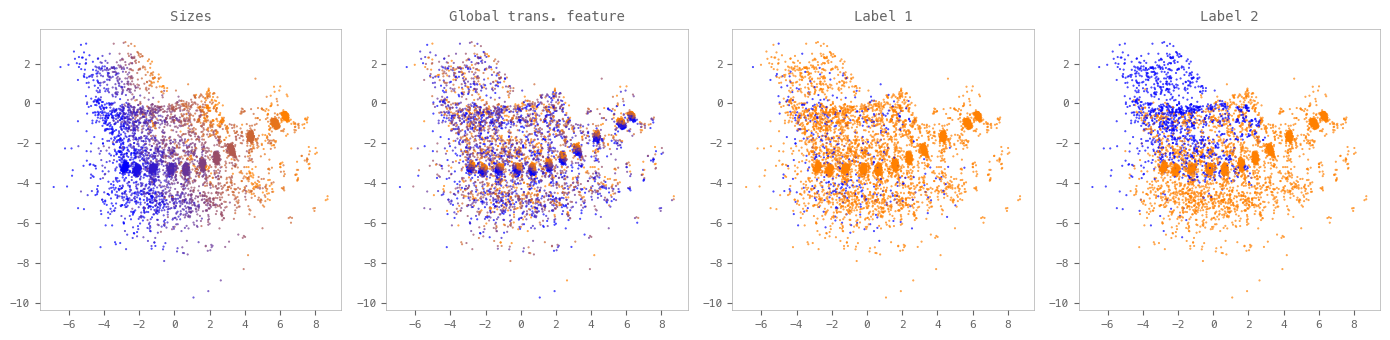

In [120]:
import matplotlib.gridspec as gridspec

def plot(ZZ, CMAPS, LABELS, SIZE=2, W=12.):

    fig = plt.figure(figsize=(W, W/len(CMAPS)))
    gs = gridspec.GridSpec(1, 4, width_ratios=[1,1,1,1])

    for i in range(4):
        plt.subplot(gs[i//len(CMAPS),i%len(CMAPS)]).scatter(ZZ[:,0], ZZ[:,1], marker='.', zorder=0, s=SIZE, c=CMAPS[i][:len(ZZ)], alpha=0.8)
        plt.subplot(gs[i//len(CMAPS),i%len(CMAPS)]).set_title(LABELS[i])
        #plt.subplot(gs[i//2,i%2]).grid(True, zorder=1)
    
    plt.tight_layout()
    plt.show()

CMAPS = [cmap_sizes, cmap_global_trans, cmap_cond0, cmap_cond1]
LABELS = ['Sizes', 'Global trans. feature', 'Label 1', 'Label 2']
ZZ = hist['z_2d']
plot(ZZ, CMAPS, LABELS, SIZE=1, W=14.)

In [121]:
z_samples = hist['z_val']
z_samples = np.nan_to_num(z_samples)
z_2D_30 = TSNE(n_components=2, perplexity=30).fit_transform(z_samples)
LABELS = ['Sizes (t-SNE, p=30)', 'Global trans. feature', 'Label 1', 'Label 2']

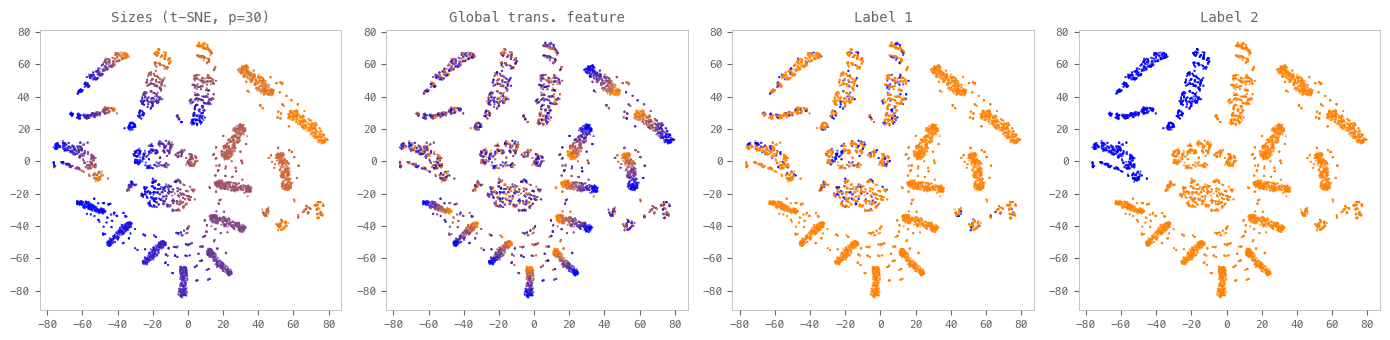

In [122]:
plot(z_2D_30, CMAPS, LABELS, SIZE=1, W=14.)

# Reconstruction

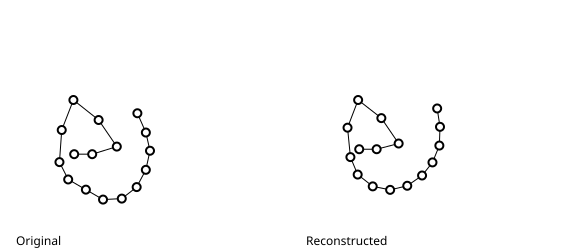

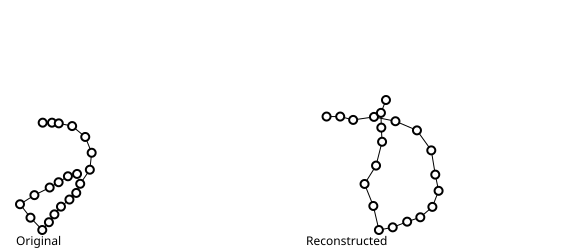

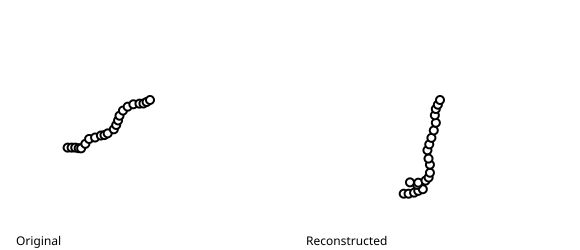

In [123]:
def get_z(protein, max_nodes, y=None):
    item = np.zeros((1, max_nodes, 2))
    inva = protein.invariant
    inva = transform_in(inva, MIN, MAX)
    item[:,:inva.shape[0],:inva.shape[1]] = inva
    sample = torch.tensor(item, dtype=torch.float32)
    sample_v = sample.view(sample.size(0),-1)
    if y is None:
        y = torch.tensor(protein.special_chunks, dtype=torch.float32)
    
    with torch.no_grad():
        Trainer.model.eval()
        z = Trainer.model.reparameterize(*Trainer.model.encode(sample_v, y))
        
    return z, y

def from_z(z, y, original=False):
    with torch.no_grad():
        Trainer.model.eval()
        recon = Trainer.model.decode(z, y)
    
    recon = recon.view(1, -1, 2).detach().numpy()
    recon = transform_out(recon, MIN, MAX)
    reconstructed = reconstruct_from_invariant(recon[0])
    if original is not False:
        reconstructed = reconstructed[:len(original)]
    
    return reconstructed
    
def in_out(protein, max_nodes, y=None):
    z, y = get_z(protein, max_nodes, y=y)
    recon = from_z(z, y, protein.coords)
    return recon

protein = DS[0]
reconstructed = in_out(protein, max_nodes=DS.max_nodes)
_ = draw([protein.coords, reconstructed], ['Original', 'Reconstructed'], size=250)

protein = DS[100]
reconstructed = in_out(protein, max_nodes=DS.max_nodes)
_ = draw([protein.coords, reconstructed], ['Original', 'Reconstructed'], size=250)

protein = DS[500]
reconstructed = in_out(protein, max_nodes=DS.max_nodes)
_ = draw([protein.coords, reconstructed], ['Original', 'Reconstructed'], size=250)

# Generation

Sequence :        achiachieadgacd
Sequence length : 15
Special chunks :  [0. 0. 0. 0. 0.]
Transformation :  2
Data :            (15, 2)



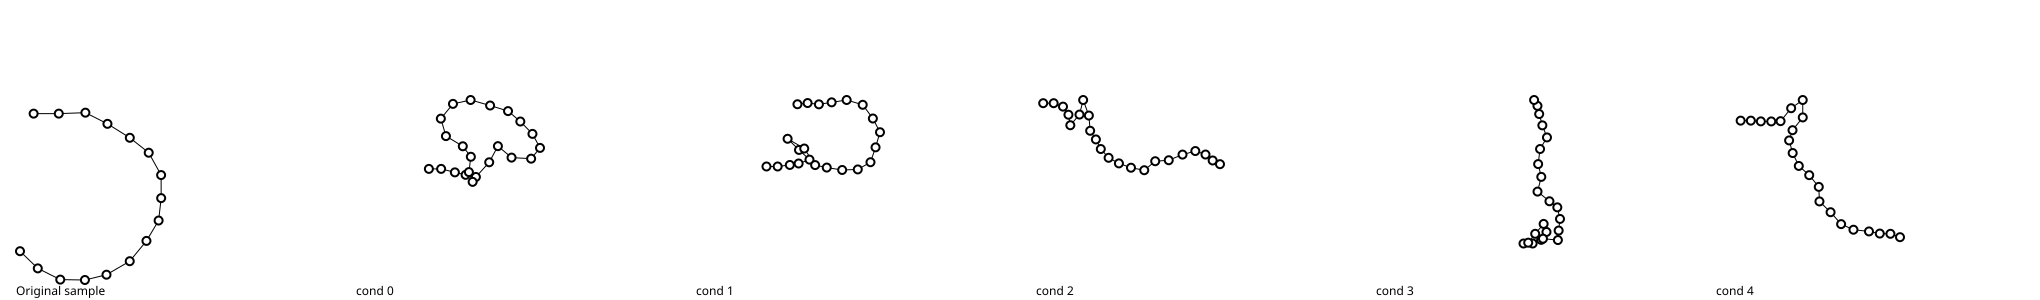

In [127]:
original_sample = DS[5]
print (original_sample)

conditions = torch.tensor(np.eye((5)), dtype=torch.float32)
generated = []
for i in range(len(conditions)):
    generated.append(in_out(protein, DS.max_nodes, y=conditions[i]))

_ = draw([original_sample.coords] + generated, ['Original sample'] + [f'cond {i}' for i in range(len(generated))], size=300)